In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import re 

In [86]:
filepaths = [
    "./EXPERTO W7/final_results_characW7.csv",
    "./EXPERTO W1/final_results_characW1.csv"
]

dataframes = {}

for filepath in filepaths:
    dataset_name = filepath.split('/')[-1].replace('.csv', '')
    df = pd.read_csv(filepath)
    print(f"Procesando archivo: {dataset_name}")
    
    # Separar métricas
    acc_df = df[df["What"] == "FINAL TEST"].copy()
    acc_df["acc"] = pd.to_numeric(acc_df["Value"], errors="coerce")
    
    f1_df = df[df["What"] == "F1 FINAL TEST"].copy()
    f1_df["f1"] = pd.to_numeric(f1_df["Value"], errors="coerce")
    
    # Seleccionar columnas clave
    acc_df = acc_df[["Frequency", "Asset", "Model", "acc"]]
    f1_df = f1_df[["Frequency", "Asset", "Model", "f1"]]
    
    # Unir por clave
    metrics_df = pd.merge(acc_df, f1_df, on=["Frequency", "Asset", "Model"], how="outer")
    
    # Renombrar
    metrics_df = metrics_df.rename(columns={
        "Frequency": "frequency",
        "Asset": "crypto",
        "Model": "model"
    })
    
    # Limpiar nombre de criptomonedas
    metrics_df["crypto"] = metrics_df["crypto"].apply(lambda x: re.sub(r'_\d+[hd]', '', x))
    
    dataframes[dataset_name] = metrics_df
    

Procesando archivo: final_results_characW7
Procesando archivo: final_results_characW1


Acc y F1 por modelo, cada barra es una criptomoneda

W1

C:\Users\raque\AppData\Local\Temp\ipykernel_1132\2065116841.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlGnBu_r')


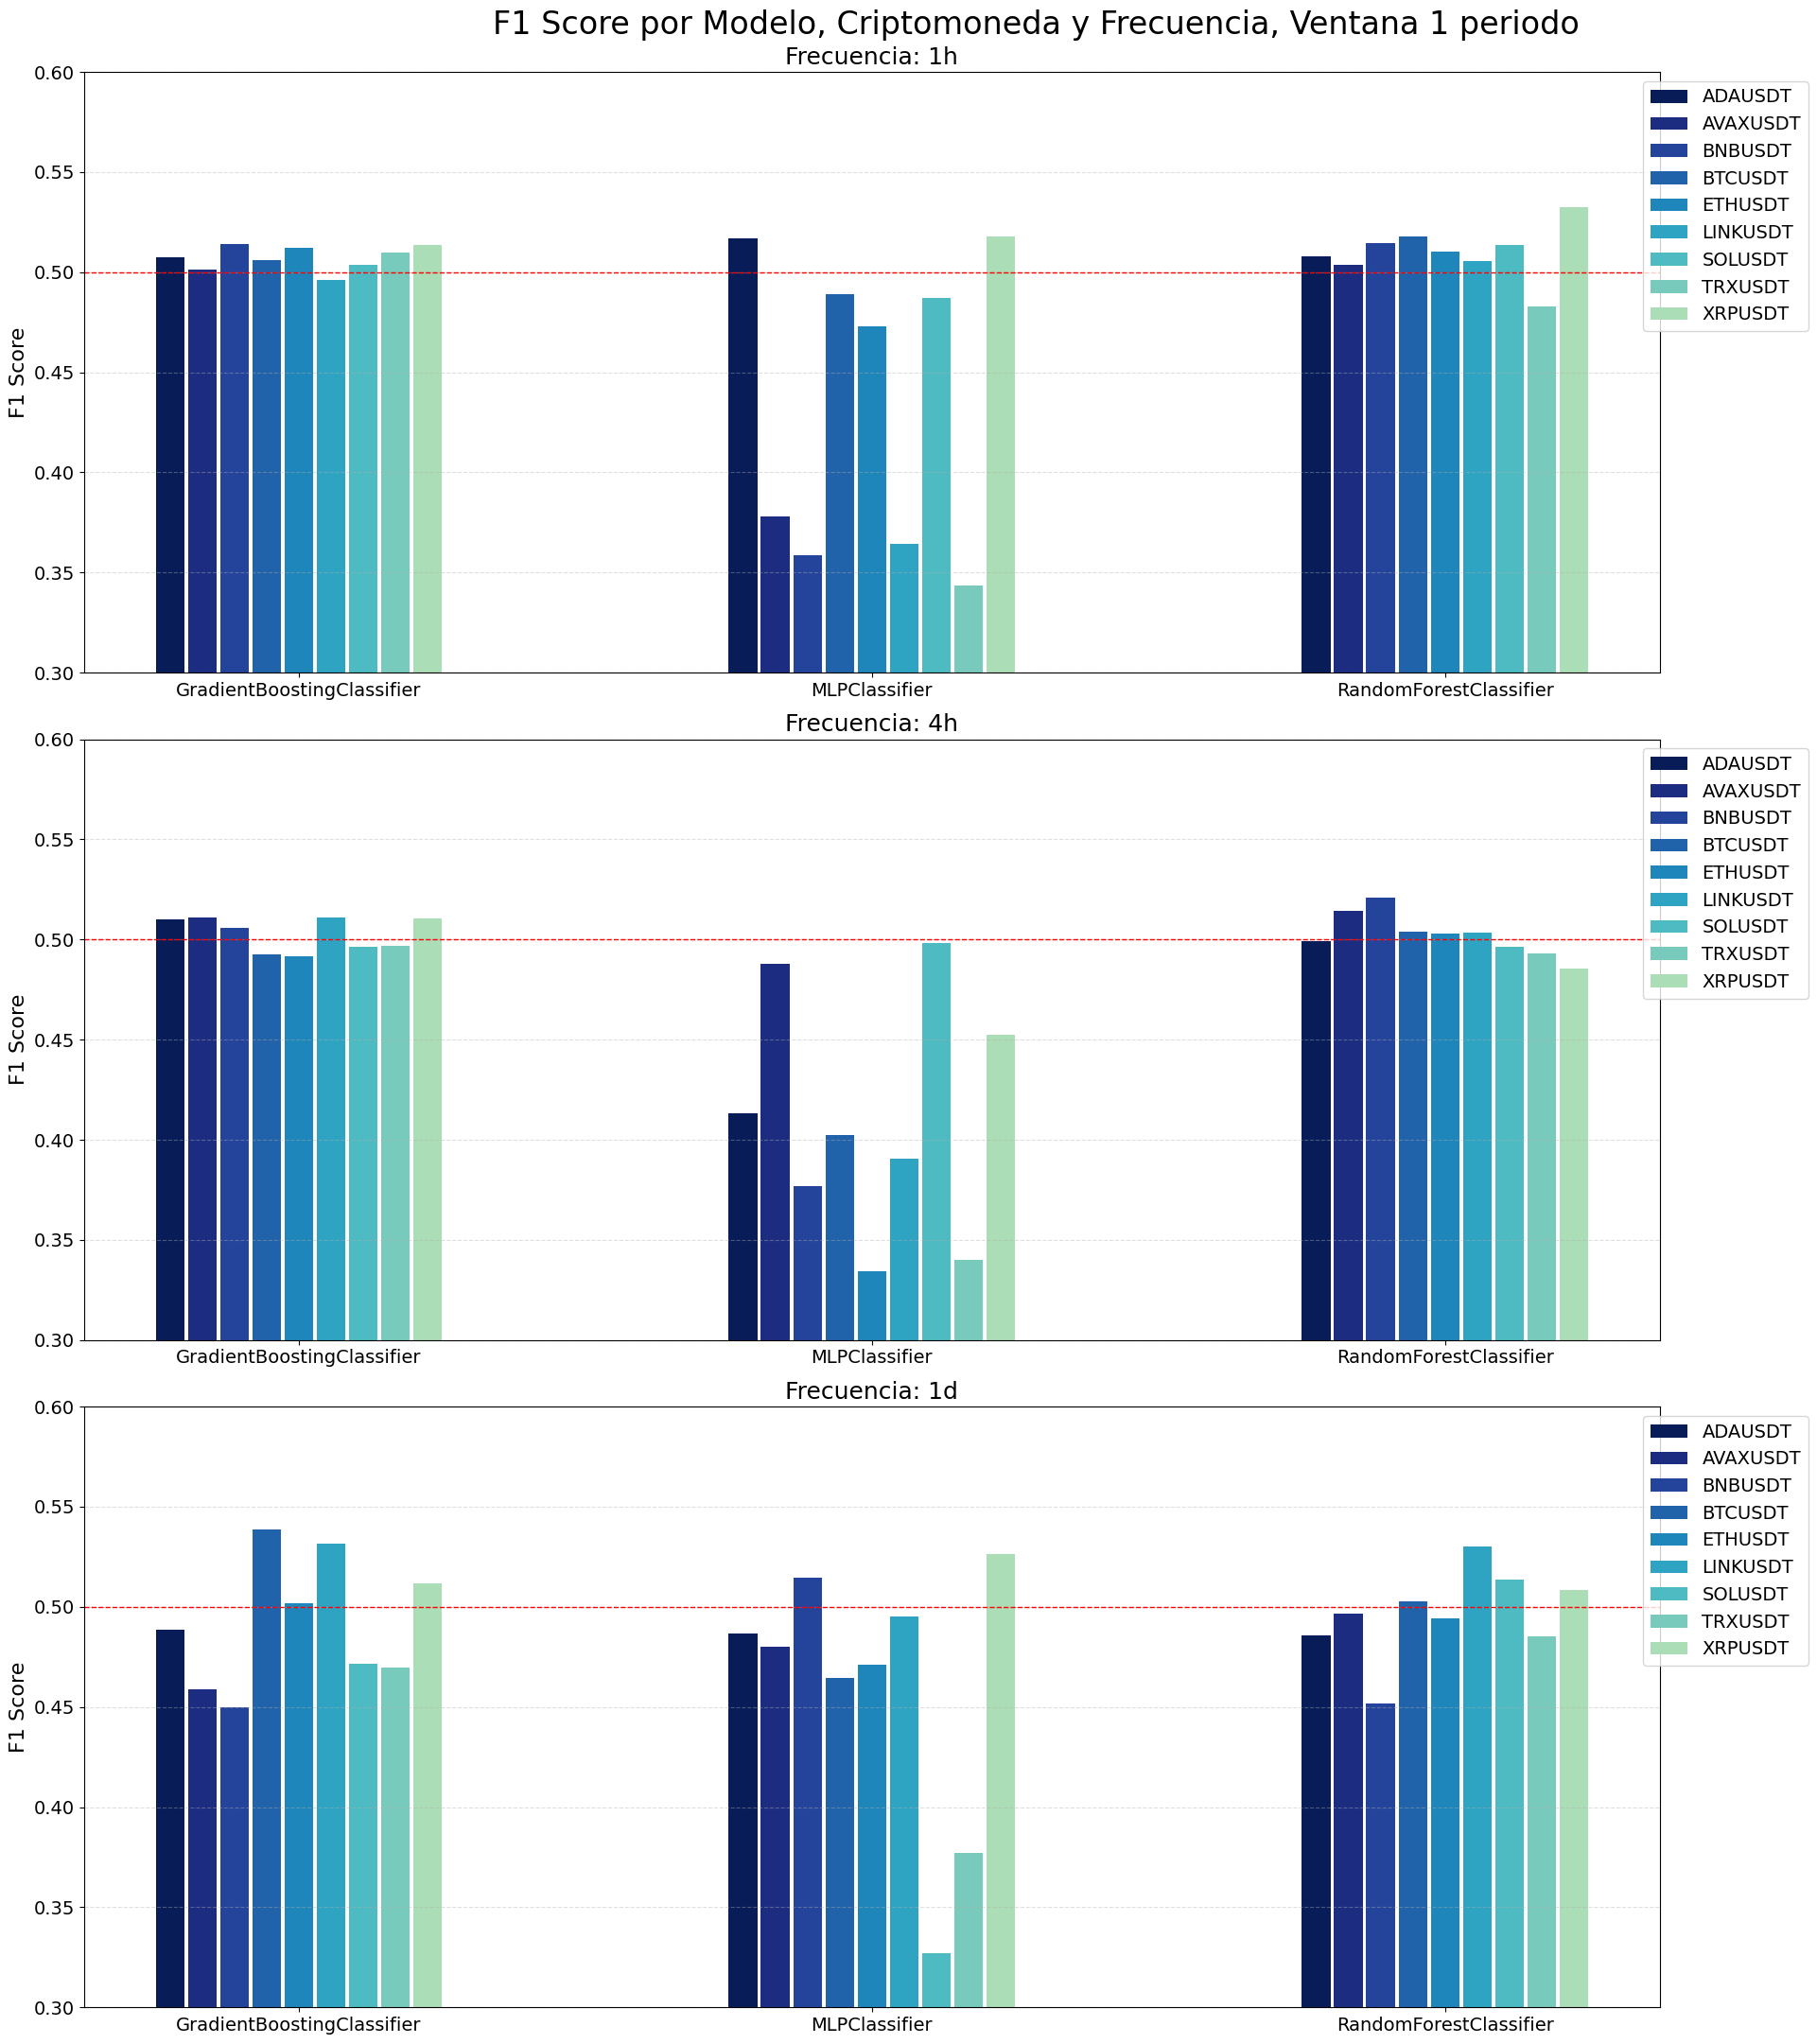

In [ ]:
metrics_df = dataframes['final_results_characW1']

# Configuración
frequencies = ["1h", "4h", "1d"]
cryptos = metrics_df["crypto"].unique()
n = len(cryptos)
cmap = cm.get_cmap('YlGnBu_r')  
colors = [cmap(i / (n - 1) * 0.7) for i in range(n)]
bar_width = 0.05

fig, axs = plt.subplots(3, 1, figsize=(22, 22), sharey=True)

for idx, freq in enumerate(frequencies):
    ax = axs[idx]
    df_freq = metrics_df[metrics_df["frequency"] == freq]
    models = df_freq["model"].unique()
    x = np.arange(len(models))
    total_bars = len(cryptos)
    offsets = np.linspace(- bar_width * total_bars / 2, bar_width * total_bars / 2, total_bars)

    for i, crypto in enumerate(cryptos):
        color_base = colors[i]
        # Agrupamos por modelo y calculamos la media del f1 para esa cripto
        values = (
            df_freq[df_freq["crypto"] == crypto]
            .groupby("model")["f1"]
            .mean()
            .reindex(models)
        )
        label = crypto
        position = x + offsets[i]
        ax.bar(position, values, width=bar_width, label=label, color=color_base, alpha=1)

    ax.set_title(f"Frecuencia: {freq}", fontsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel("F1 Score", fontsize=16)


axs[0].set_ylim(0.3, 0.6)

# Leyenda común
for ax in axs:
    ax.legend(loc="upper right", bbox_to_anchor=(1.10, 1), fontsize=14)

fig.suptitle("F1 Score por Modelo, Criptomoneda y Frecuencia, Ventana 1 periodo", fontsize=24)
plt.tight_layout()
plt.subplots_adjust(top=0.95, right=0.80)
plt.show()

W7

C:\Users\raque\AppData\Local\Temp\ipykernel_1132\2900062371.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlGnBu_r')


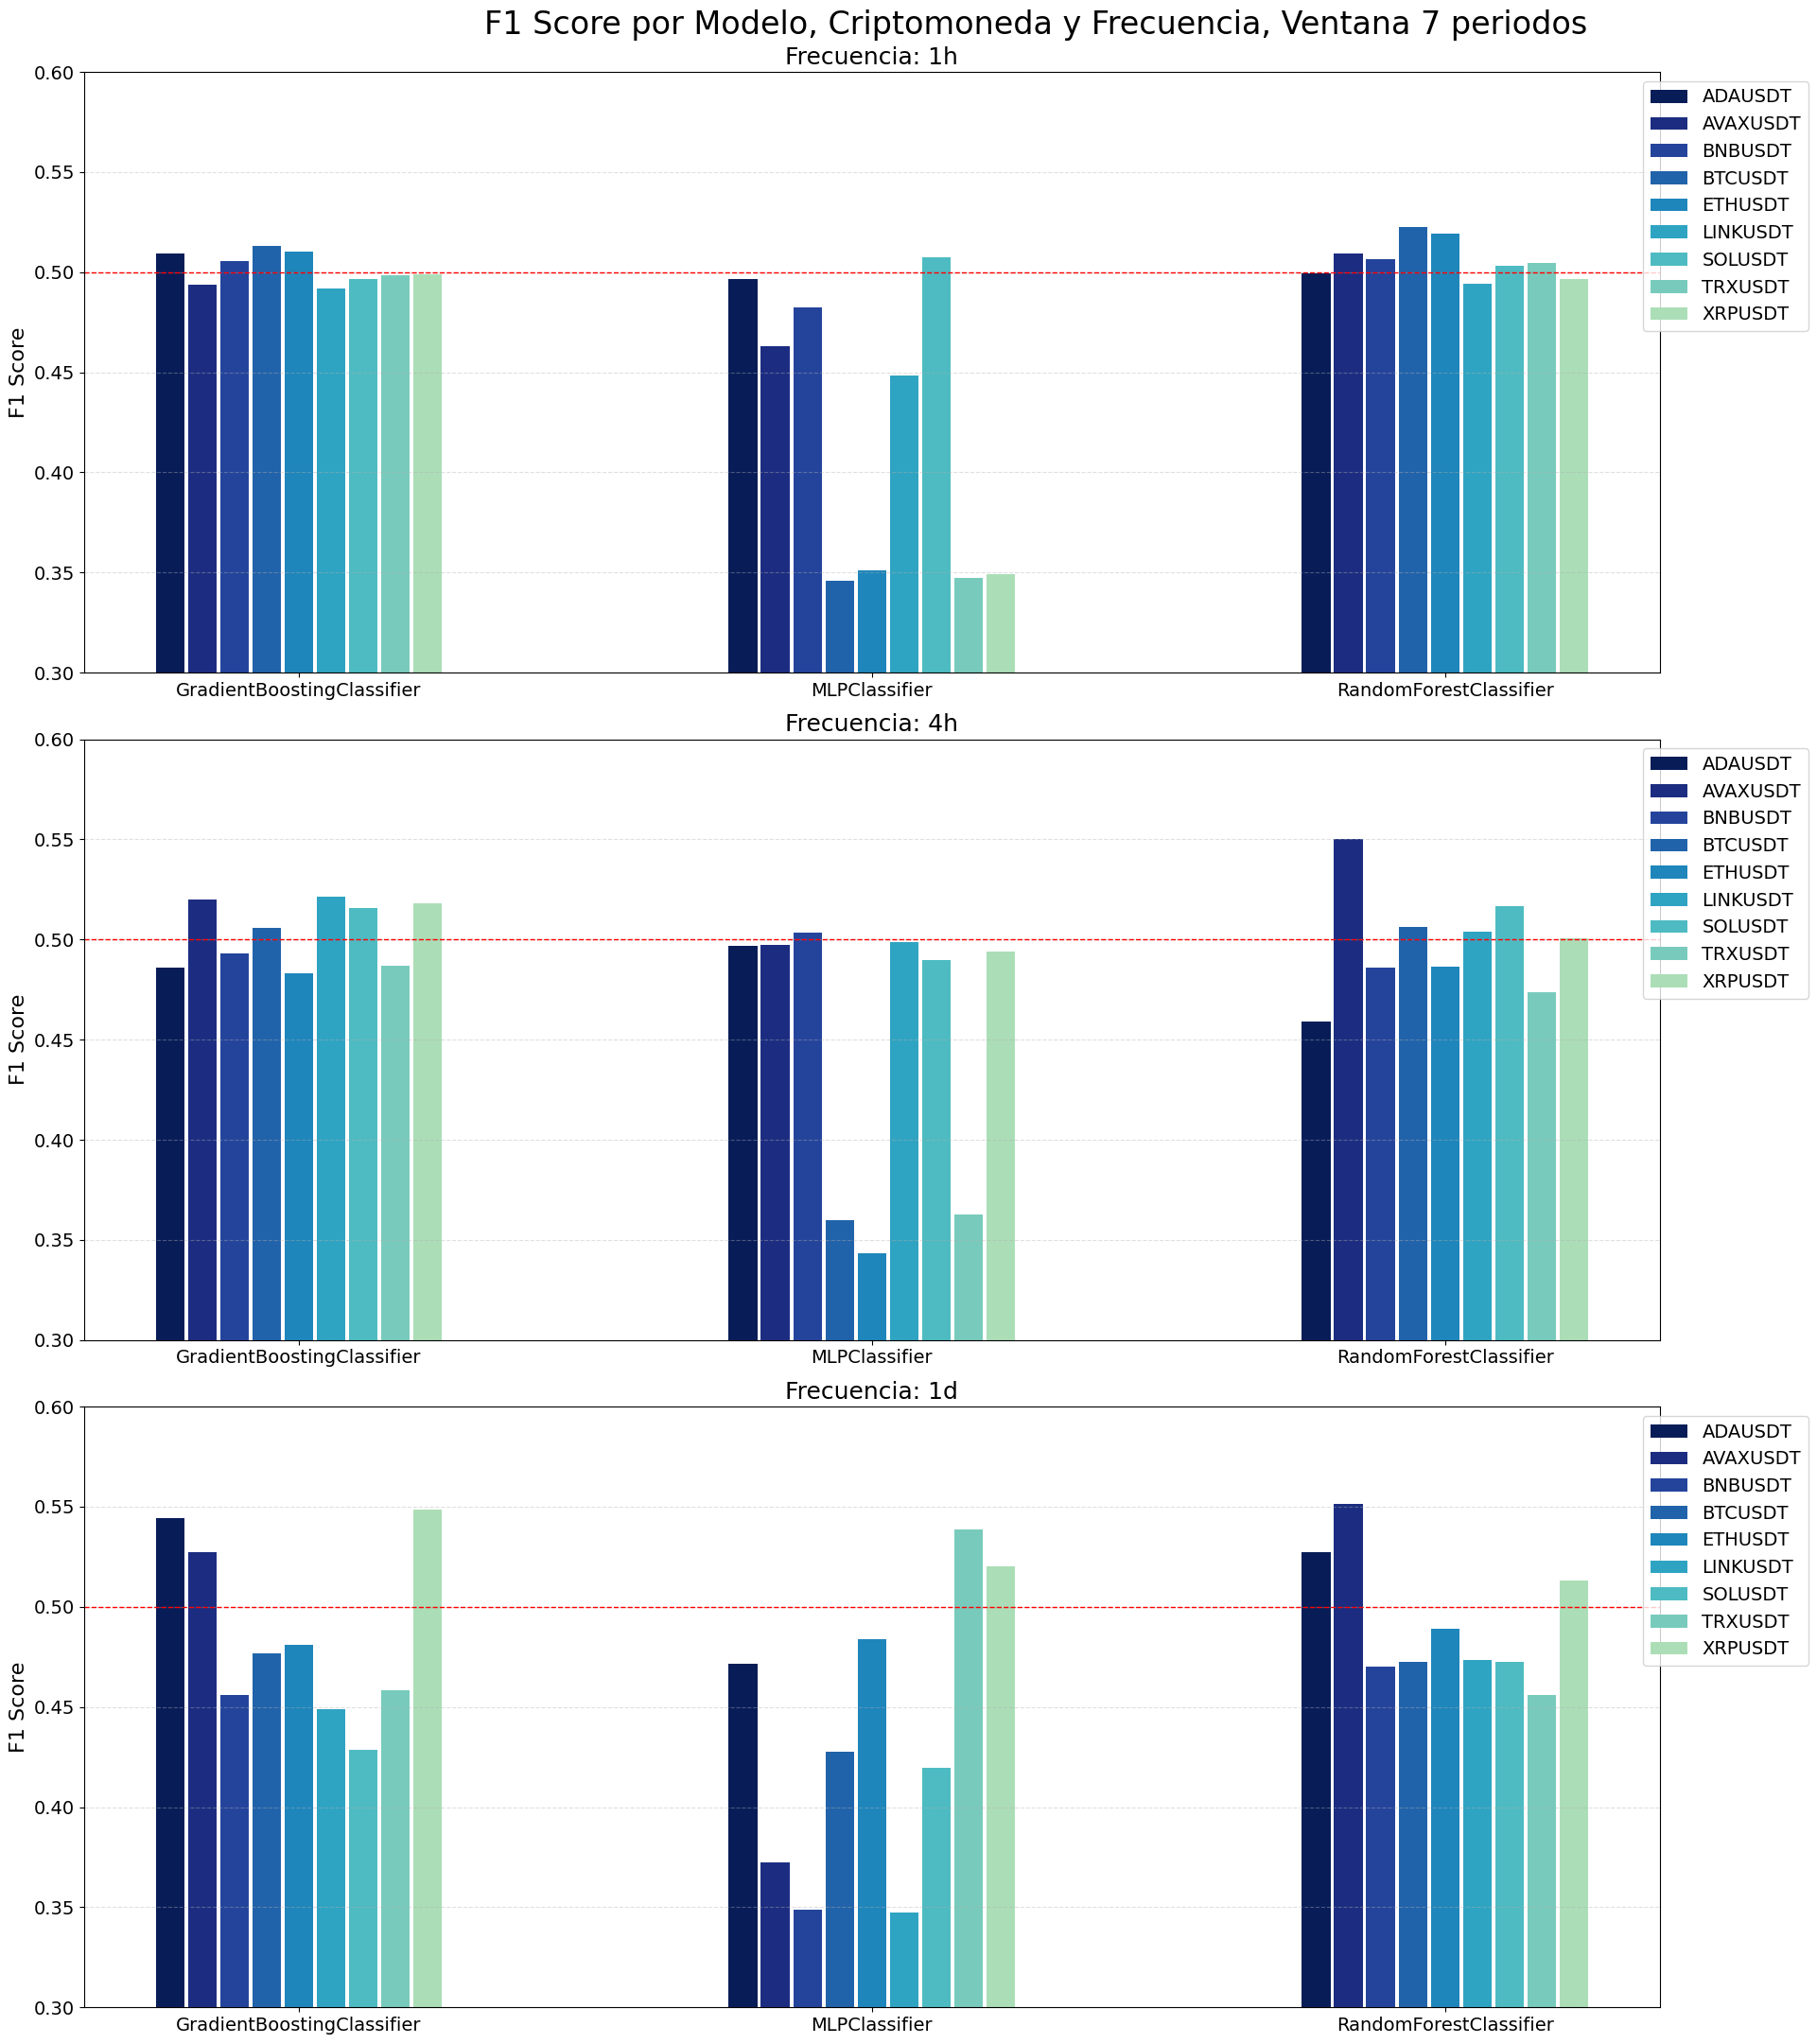

In [ ]:
metrics_df = dataframes['final_results_characW7']

# Configuración
frequencies = ["1h", "4h", "1d"]
cryptos = metrics_df["crypto"].unique()
n = len(cryptos)
cmap = cm.get_cmap('YlGnBu_r')  
colors = [cmap(i / (n - 1) * 0.7) for i in range(n)]
bar_width = 0.05

fig, axs = plt.subplots(3, 1, figsize=(22, 22), sharey=True)

for idx, freq in enumerate(frequencies):
    ax = axs[idx]
    df_freq = metrics_df[metrics_df["frequency"] == freq]
    models = df_freq["model"].unique()
    x = np.arange(len(models))
    total_bars = len(cryptos)
    offsets = np.linspace(- bar_width * total_bars / 2, bar_width * total_bars / 2, total_bars)

    for i, crypto in enumerate(cryptos):
        color_base = colors[i]
        # Agrupamos por modelo y calculamos la media del f1 para esa cripto
        values = (
            df_freq[df_freq["crypto"] == crypto]
            .groupby("model")["f1"]
            .mean()
            .reindex(models)
        )
        label = crypto
        position = x + offsets[i]
        ax.bar(position, values, width=bar_width, label=label, color=color_base, alpha=1)

    ax.set_title(f"Frecuencia: {freq}", fontsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel("F1 Score", fontsize=16)


axs[0].set_ylim(0.3, 0.6)

# Leyenda común
for ax in axs:
    ax.legend(loc="upper right", bbox_to_anchor=(1.10, 1), fontsize=14)

fig.suptitle("F1 Score por Modelo, Criptomoneda y Frecuencia, Ventana 7 periodos", fontsize=24)
plt.tight_layout()
plt.subplots_adjust(top=0.95, right=0.80)
plt.show()

Comparación entre accuracy y f1

W1

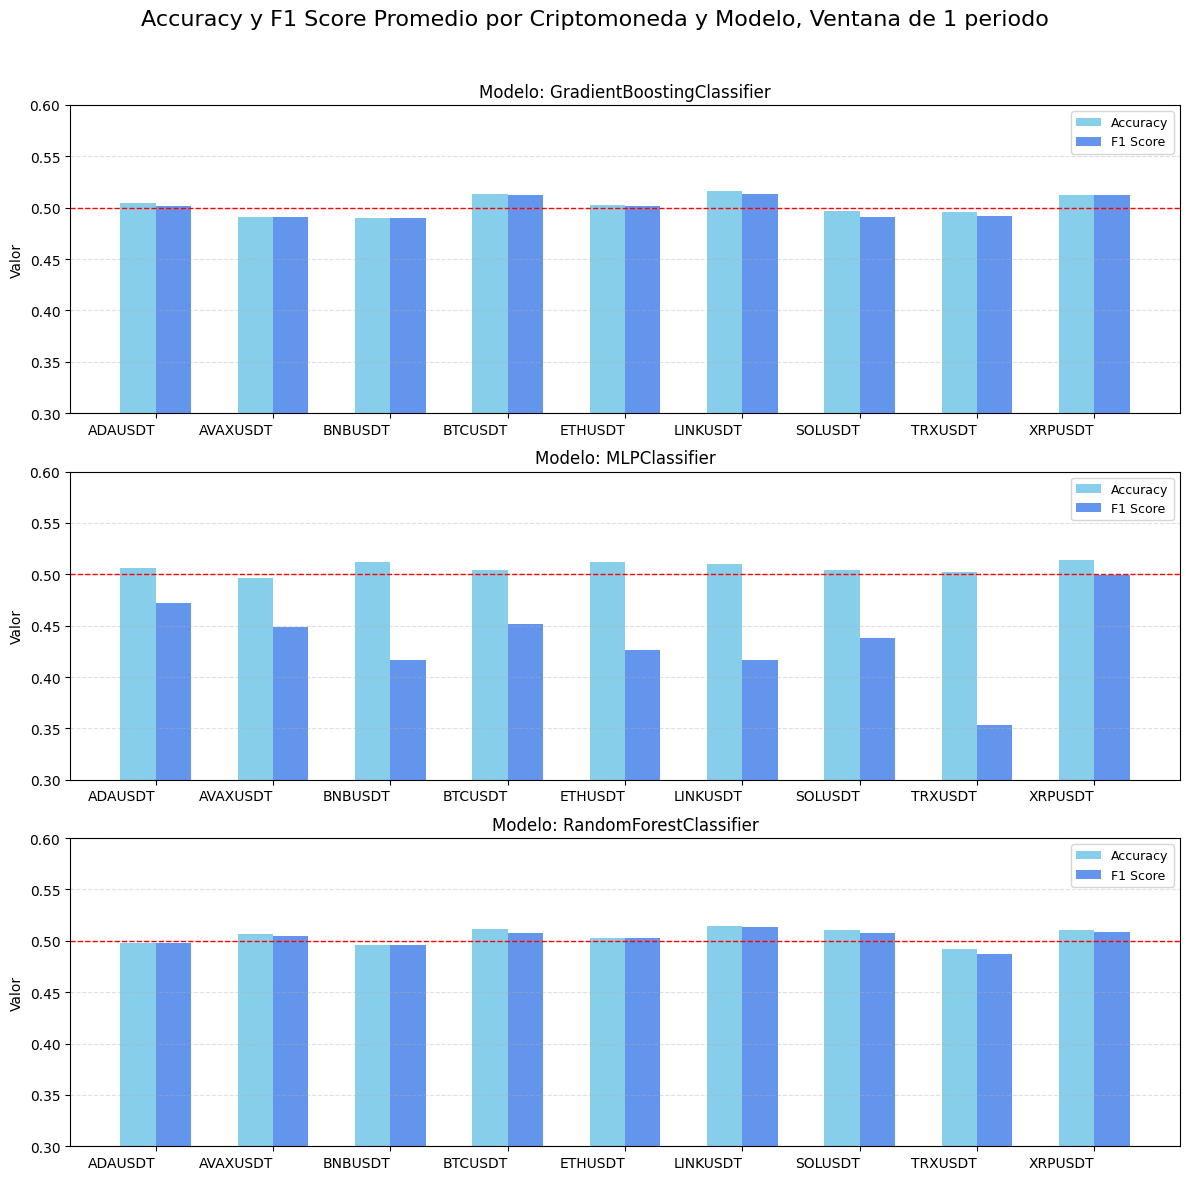

In [89]:
metrics_df = dataframes['final_results_characW1']
# Unir por clave
metrics_df = pd.merge(acc_df, f1_df, on=["Frequency", "Asset", "Model"], how="outer")

# Renombrar
metrics_df = metrics_df.rename(columns={
    "Frequency": "frequency",
    "Asset": "crypto",
    "Model": "model"
})

# Limpiar nombre de criptomonedas
metrics_df["crypto"] = metrics_df["crypto"].apply(lambda x: re.sub(r'_\d+[hd]', '', x))

# Crear subplots dinámicos (uno por modelo)
# Agrupar por modelo y cripto, promediando métricas
avg_df = metrics_df.groupby(["model", "crypto"])[["acc", "f1"]].mean().reset_index()

frequencies = ["1h", "4h", "1d"]
models = avg_df["model"].unique()
n_models = len(models)
fig, axs = plt.subplots(n_models, 1, figsize=(12, 4 * n_models), sharey=True)

for idx, model in enumerate(models):
    ax = axs[idx]
    df_model = avg_df[avg_df["model"] == model]
    cryptos = df_model["crypto"].values
    acc = df_model["acc"].values
    f1 = df_model["f1"].values
    x = np.arange(len(cryptos))

    ax.bar(x - 0.15, acc, width=0.3, label="Accuracy", color="skyblue")
    ax.bar(x + 0.15, f1, width=0.3, label="F1 Score", color="cornflowerblue")
    ax.set_xticks(x)
    ax.set_xticklabels(cryptos, ha="right", fontsize=10)
    ax.set_title(f"Modelo: {model}", fontsize=12)
    ax.set_ylim(0.3, 0.6)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1)
    ax.legend(fontsize=9)
    ax.set_ylabel("Valor")

fig.suptitle("Accuracy y F1 Score Promedio por Criptomoneda y Modelo, Ventana de 1 periodo", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

W7

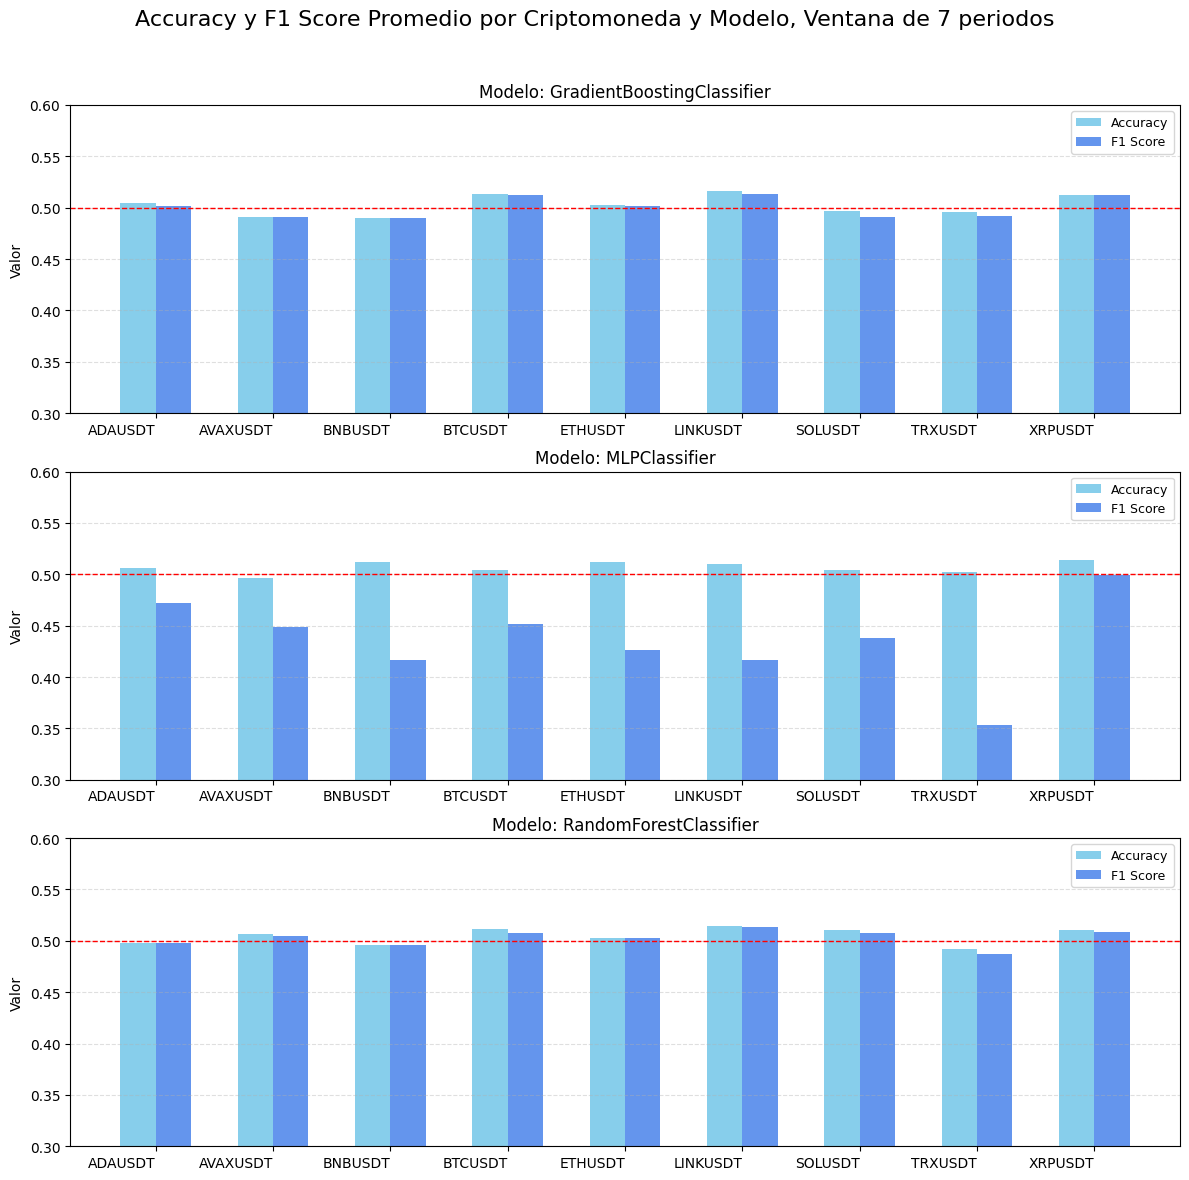

In [90]:
metrics_df = dataframes['final_results_characW7']
# Unir por clave
metrics_df = pd.merge(acc_df, f1_df, on=["Frequency", "Asset", "Model"], how="outer")

# Renombrar
metrics_df = metrics_df.rename(columns={
    "Frequency": "frequency",
    "Asset": "crypto",
    "Model": "model"
})

# Limpiar nombre de criptomonedas
metrics_df["crypto"] = metrics_df["crypto"].apply(lambda x: re.sub(r'_\d+[hd]', '', x))

# Crear subplots dinámicos (uno por modelo)
# Agrupar por modelo y cripto, promediando métricas
avg_df = metrics_df.groupby(["model", "crypto"])[["acc", "f1"]].mean().reset_index()

frequencies = ["1h", "4h", "1d"]
models = avg_df["model"].unique()
n_models = len(models)
fig, axs = plt.subplots(n_models, 1, figsize=(12, 4 * n_models), sharey=True)

for idx, model in enumerate(models):
    ax = axs[idx]
    df_model = avg_df[avg_df["model"] == model]
    cryptos = df_model["crypto"].values
    acc = df_model["acc"].values
    f1 = df_model["f1"].values
    x = np.arange(len(cryptos))

    ax.bar(x - 0.15, acc, width=0.3, label="Accuracy", color="skyblue")
    ax.bar(x + 0.15, f1, width=0.3, label="F1 Score", color="cornflowerblue")
    ax.set_xticks(x)
    ax.set_xticklabels(cryptos, ha="right", fontsize=10)
    ax.set_title(f"Modelo: {model}", fontsize=12)
    ax.set_ylim(0.3, 0.6)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1)
    ax.legend(fontsize=9)
    ax.set_ylabel("Valor")

fig.suptitle("Accuracy y F1 Score Promedio por Criptomoneda y Modelo, Ventana de 7 periodos", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

Tabla comparación de ventanas por cripto. Solo para el mejor modelo RF

In [ ]:
columna_f1 = "f1" 
frecuencias = set()
for df in dataframes.values():
    frecuencias.update(df["frequency"].unique())

for freq in frecuencias:
    tablas_resultado = []

    for nombre_dataset, df in dataframes.items():
        # Filtrar por modelo y frecuencia
        df_filtrado = df[
            (df["model"] == "RandomForestClassifier") &
            (df["frequency"] == freq)
        ]

        # Calcular media por criptomoneda
        resumen = df_filtrado.groupby("crypto")[columna_f1].mean().reset_index()
        resumen["ventana"] = nombre_dataset  # la ventana es el nombre del dataset

        tablas_resultado.append(resumen)

    # Unir todos los resultados
    df_comparativo = pd.concat(tablas_resultado)

    # Pivot: filas=cripto, columnas=ventana, valores=f1
    tabla_f1 = df_comparativo.pivot(index="crypto", columns="ventana", values=columna_f1)

    # Añadir fila de media
    tabla_f1.loc["Media"] = tabla_f1.mean()

    tabla_f1 = tabla_f1.round(4)

    # Mostrar
    print(f"\nF1-score medio por criptomoneda y ventana temporal - Frecuencia {freq}:")
    display(tabla_f1)


F1-score medio por criptomoneda y ventana temporal - Frecuencia 1d:


ventana,final_results_characW1,final_results_characW7
crypto,,
ADAUSDT,0.4856,0.5272
AVAXUSDT,0.4968,0.5514
BNBUSDT,0.4519,0.4702
BTCUSDT,0.5028,0.4725
ETHUSDT,0.4942,0.4891
LINKUSDT,0.5302,0.4733
SOLUSDT,0.5134,0.4724
TRXUSDT,0.4854,0.4558
XRPUSDT,0.5086,0.5133



F1-score medio por criptomoneda y ventana temporal - Frecuencia 1h:


ventana,final_results_characW1,final_results_characW7
crypto,,
ADAUSDT,0.5079,0.4994
AVAXUSDT,0.5035,0.5093
BNBUSDT,0.5143,0.5064
BTCUSDT,0.5176,0.5223
ETHUSDT,0.5102,0.5191
LINKUSDT,0.5055,0.4941
SOLUSDT,0.5135,0.5031
TRXUSDT,0.4827,0.5046
XRPUSDT,0.5324,0.4964



F1-score medio por criptomoneda y ventana temporal - Frecuencia 4h:


ventana,final_results_characW1,final_results_characW7
crypto,,
ADAUSDT,0.4990,0.4590
AVAXUSDT,0.5141,0.5501
BNBUSDT,0.5210,0.4860
BTCUSDT,0.5039,0.5062
ETHUSDT,0.5030,0.4863
LINKUSDT,0.5033,0.5039
SOLUSDT,0.4963,0.5164
TRXUSDT,0.4930,0.4736
XRPUSDT,0.4854,0.5006


In [ ]:
columna_f1 = "f1" 

# Lista para almacenar resultados
tablas_resultado = []

for nombre_dataset, df in dataframes.items():
    # Filtrar por modelo
    df_filtrado = df[df['model'] == 'RandomForestClassifier']

    resumen = df_filtrado.groupby('crypto')[columna_f1].mean().reset_index()
    resumen['ventana'] = nombre_dataset  # la ventana es el nombre del dataset

    tablas_resultado.append(resumen)

# Combinar todos los resultados
df_comparativo = pd.concat(tablas_resultado)

# Pivot: filas=cripto, columnas=ventana, celdas=f1
tabla_f1 = df_comparativo.pivot(index='crypto', columns='ventana', values=columna_f1)

# Añadir fila de media
tabla_f1.loc['Media'] = tabla_f1.mean()

tabla_f1 = tabla_f1.round(4)
# Mostrar tabla
print(" F1-score medio por criptomoneda y ventana temporal (incluye media):")
display(tabla_f1)

 F1-score medio por criptomoneda y ventana temporal (incluye media):


ventana,final_results_characW1,final_results_characW7
crypto,,
ADAUSDT,0.4975,0.4952
AVAXUSDT,0.5048,0.5369
BNBUSDT,0.4958,0.4875
BTCUSDT,0.5081,0.5004
ETHUSDT,0.5025,0.4982
LINKUSDT,0.5130,0.4904
SOLUSDT,0.5077,0.4973
TRXUSDT,0.4871,0.4780
XRPUSDT,0.5088,0.5034


Tabla comparación de ventanas por freq

In [ ]:
columna_f1 = "f1"

# Lista para almacenar resultados
tablas_resultado = []

for nombre_dataset, df in dataframes.items():
    # Filtrar por modelo
    df_filtrado = df[df['model'] == 'RandomForestClassifier']

    resumen = df_filtrado.groupby('frequency')[columna_f1].mean().reset_index()
    resumen['ventana'] = nombre_dataset  # la ventana es el nombre del dataset

    tablas_resultado.append(resumen)

# Combinar todos los resultados
df_comparativo = pd.concat(tablas_resultado)

# Pivot: filas=cripto, columnas=ventana, celdas=f1
tabla_f1 = df_comparativo.pivot(index='frequency', columns='ventana', values=columna_f1)

# Añadir fila de media
tabla_f1.loc['Media'] = tabla_f1.mean()

tabla_f1 = tabla_f1.round(4)
# Mostrar tabla
print(" F1-score medio por criptomoneda y ventana temporal (incluye media):")
display(tabla_f1)

 F1-score medio por criptomoneda y ventana temporal (incluye media):


ventana,final_results_characW1,final_results_characW7
frequency,,
1d,0.4966,0.4917
1h,0.5097,0.5061
4h,0.5021,0.4980
Media,0.5028,0.4986


In [94]:
tablas_por_modelo = {}

for nombre_dataset, df in dataframes.items():
    if not all(col in df.columns for col in ['model', 'crypto', 'f1']):
        print(f" El dataset '{nombre_dataset}' no contiene las columnas necesarias ('model', 'crypto', 'f1')")
        continue

    # Agrupar por modelo y cripto, calcular media del f1
    tabla = df.groupby(['crypto', 'model'])['f1'].mean().unstack()

    tabla.loc['Media'] = tabla.mean()
    tabla = tabla.round(4)

    print(f"\n F1-score medio por modelo y criptomoneda - {nombre_dataset}")
    display(tabla)

    tablas_por_modelo[nombre_dataset] = tabla



 F1-score medio por modelo y criptomoneda - final_results_characW7


model,GradientBoostingClassifier,MLPClassifier,RandomForestClassifier
crypto,,,
ADAUSDT,0.5131,0.4884,0.4952
AVAXUSDT,0.5136,0.4441,0.5369
BNBUSDT,0.4848,0.4448,0.4875
BTCUSDT,0.4984,0.3777,0.5004
ETHUSDT,0.4913,0.3927,0.4982
LINKUSDT,0.4872,0.4315,0.4904
SOLUSDT,0.4803,0.4722,0.4973
TRXUSDT,0.4812,0.4162,0.4780
XRPUSDT,0.5219,0.4546,0.5034



 F1-score medio por modelo y criptomoneda - final_results_characW1


model,GradientBoostingClassifier,MLPClassifier,RandomForestClassifier
crypto,,,
ADAUSDT,0.5020,0.4724,0.4975
AVAXUSDT,0.4905,0.4487,0.5048
BNBUSDT,0.4898,0.4165,0.4958
BTCUSDT,0.5125,0.4520,0.5081
ETHUSDT,0.5018,0.4262,0.5025
LINKUSDT,0.5130,0.4167,0.5130
SOLUSDT,0.4906,0.4377,0.5077
TRXUSDT,0.4921,0.3535,0.4871
XRPUSDT,0.5120,0.4989,0.5088
